In [9]:
import pandas as pd
import numpy as np
import time
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import optuna
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [10]:
X_train_df = pd.read_csv('/kaggle/input/datasets/lacthai/ready-train/X_train.csv')
X_test_df  = pd.read_csv('/kaggle/input/datasets/lacthai/ready-train/X_test.csv')
y_train_df = pd.read_csv('/kaggle/input/datasets/lacthai/ready-train/y_train.csv')
y_test_df  = pd.read_csv('/kaggle/input/datasets/lacthai/ready-train/y_test.csv')

X_train_full = X_train_df.values
X_test_full  = X_test_df.values
y_train = y_train_df.values  # shape (n, 1)
y_test  = y_test_df.values

# Scale target only (no log)
scaler_y = StandardScaler()
y_train_sc = scaler_y.fit_transform(y_train)
y_test_sc  = scaler_y.transform(y_test)

print(f'X_train: {X_train_full.shape} | X_test: {X_test_full.shape}')
print(f'y mean={y_train.mean():.0f}  std={y_train.std():.0f}')

X_train: (16512, 22) | X_test: (4128, 22)
y mean=207195  std=115619


In [11]:
# PCA – retain 95 % variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_full)
X_test_pca  = pca.transform(X_test_full)
print(f'PCA: {X_train_pca.shape[1]} components')

# Mutual Information – top 10
mi_scores = mutual_info_regression(X_train_full, y_train_sc.squeeze(), random_state=42)
top10_idx = np.argsort(mi_scores)[-10:]
X_train_mi = X_train_full[:, top10_idx]
X_test_mi  = X_test_full[:, top10_idx]
print(f'MI Top-10 feature indices: {top10_idx}')

SCENARIOS = [
    ('Full Features', X_train_full, X_test_full),
    ('PCA Features',  X_train_pca,  X_test_pca),
    ('MI Top-10',     X_train_mi,   X_test_mi),
]

PCA: 9 components
MI Top-10 feature indices: [20 18 13 19 14  1 21 12  7  0]


In [12]:
# ─── Linear Regression (Scratch) ────────────────────────
class LinearRegressionScratch:
    def __init__(self, lr=0.001, epochs=1000):
        self.lr = lr; self.epochs = epochs
        self.w = self.b = None
        self.loss_hist = []

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros((d, 1)); self.b = 0.0; self.loss_hist = []
        for _ in range(self.epochs):
            yp = X @ self.w + self.b
            err = yp - y
            self.loss_hist.append(float(np.mean(err**2)))
            self.w -= self.lr * (2/n) * (X.T @ err)
            self.b -= self.lr * (2/n) * float(np.sum(err))

    def predict(self, X):
        return X @ self.w + self.b


# ─── SVR (Scratch) ───────────────────────────────────────
class SVRScratch:
    def __init__(self, lr=0.005, epochs=1000, C=1.0, epsilon=0.1, reg=0.1):
        self.lr=lr; self.epochs=epochs; self.C=C
        self.epsilon=epsilon; self.reg=reg
        self.w = self.b = None
        self.loss_hist = []

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros((d, 1)); self.b = 0.0; self.loss_hist = []
        for _ in range(self.epochs):
            yp  = X @ self.w + self.b
            err = y - yp
            loss = 0.5*self.reg*np.sum(self.w**2) + self.C*np.mean(np.maximum(0, np.abs(err)-self.epsilon))
            self.loss_hist.append(float(loss))
            mp = (err >  self.epsilon).squeeze()
            mn = (err < -self.epsilon).squeeze()
            gW = np.zeros_like(X)
            gW[mp] = -X[mp]; gW[mn] = X[mn]
            gW = np.mean(gW, axis=0, keepdims=True).T
            gb = np.zeros(n)
            gb[mp] = -1.0; gb[mn] = 1.0
            self.w -= self.lr*(self.reg*self.w + self.C*gW)
            self.b -= self.lr*self.C*np.mean(gb)

    def predict(self, X):
        return X @ self.w + self.b


# ─── PyTorch MLP ─────────────────────────────────────────
class HouseDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

class MLPRegressor(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),   nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

def train_mlp(X_tr, y_tr, X_val, y_val, epochs=60, batch=256, lr=0.005, wd=0.001):
    ds = HouseDataset(X_tr, y_tr)
    loader = DataLoader(ds, batch_size=batch, shuffle=True)
    model = MLPRegressor(X_tr.shape[1]).to(device)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    crit  = nn.MSELoss()
    
    Xv = torch.tensor(X_val, dtype=torch.float32).to(device)
    yv = torch.tensor(y_val, dtype=torch.float32).to(device)
    
    tr_hist, val_hist, r2_hist = [], [], []
    
    for ep in range(epochs):
        model.train()
        ep_loss = 0
        for bX, by in loader:
            bX, by = bX.to(device), by.to(device)
            opt.zero_grad()
            l = crit(model(bX), by)
            l.backward()
            opt.step()
            ep_loss += l.item() * len(bX)
            
        train_loss = ep_loss / len(X_tr)
        tr_hist.append(train_loss)
        
        # Validation tại mỗi Epoch
        model.eval()
        with torch.no_grad():
            val_preds_scaled = model(Xv)
            vl = crit(val_preds_scaled, yv).item()
            val_hist.append(vl)
            
            # Tính R2 score của Epoch này
            preds_orig = inv(val_preds_scaled.cpu().numpy())
            y_val_orig = inv(yv.cpu().numpy())
            val_r2 = r2_score(y_val_orig, preds_orig)
            r2_hist.append(val_r2)
            
        sched.step(vl)
        
        # Dòng in ra kết quả như ảnh của bạn (In ra mỗi epoch hoặc mỗi 10 epochs tùy ý)
        # Ở đây in ra mỗi epoch:
        print(f'Epoch [{ep+1}/20], Train Loss: {train_loss:.4f}, Validation Loss: {vl:.4f}, Validation R²: {val_r2:.2f}')
        
    return model, tr_hist, val_hist, r2_hist

print('Model classes defined.')

Model classes defined.


In [13]:
def metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-5))) * 100
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

def inv(arr):
    """Inverse-transform scaled predictions back to USD."""
    return scaler_y.inverse_transform(arr.reshape(-1,1))

print('Helper functions ready.')

Helper functions ready.


In [14]:
# ── Tune Linear Regression with Optuna ─────────────────────
print('Tuning Linear Regression using Optuna...')
def lr_objective(trial):
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    epochs = trial.suggest_int('epochs', 500, 1000)
    
    m = LinearRegressionScratch(lr=lr, epochs=epochs)
    m.fit(X_train_full, y_train_sc)
    p = inv(m.predict(X_test_full))
    return r2_score(y_test, p)

lr_study = optuna.create_study(direction='maximize')
lr_study.optimize(lr_objective, n_trials=10)
best_lr_params = lr_study.best_params
print(f'  Best LR params: {best_lr_params} | Best R2: {lr_study.best_value:.4f}')

# Display Top Trials
print(lr_study.trials_dataframe().sort_values('value', ascending=False)[['params_lr', 'params_epochs', 'value']].head(5).to_string(index=False))

[I 2026-07-05 14:00:38,966] A new study created in memory with name: no-name-63599db0-779f-4f81-abfe-475750d81bea


Tuning Linear Regression using Optuna...


[I 2026-07-05 14:00:39,215] Trial 0 finished with value: 0.5839053067353843 and parameters: {'lr': 0.014454880569457765, 'epochs': 666}. Best is trial 0 with value: 0.5839053067353843.
[I 2026-07-05 14:00:39,556] Trial 1 finished with value: 0.3935308446670438 and parameters: {'lr': 0.00013137523297127962, 'epochs': 945}. Best is trial 0 with value: 0.5839053067353843.
[I 2026-07-05 14:00:39,750] Trial 2 finished with value: 0.5994524955511342 and parameters: {'lr': 0.0011739188232395615, 'epochs': 605}. Best is trial 2 with value: 0.5994524955511342.
[I 2026-07-05 14:00:39,912] Trial 3 finished with value: 0.5753855792797236 and parameters: {'lr': 0.007021647031725497, 'epochs': 534}. Best is trial 2 with value: 0.5994524955511342.
[I 2026-07-05 14:00:40,130] Trial 4 finished with value: 0.5217940608225371 and parameters: {'lr': 0.00036061454311032867, 'epochs': 719}. Best is trial 2 with value: 0.5994524955511342.
[I 2026-07-05 14:00:40,430] Trial 5 finished with value: 0.57642958962

  Best LR params: {'lr': 0.033226146739212196, 'epochs': 589} | Best R2: 0.6004
 params_lr  params_epochs    value
  0.033226            589 0.600421
  0.001174            605 0.599452
  0.010748            907 0.584180
  0.014455            666 0.583905
  0.000525            940 0.583605


In [15]:
# ── Tune SVR Scratch with Optuna ──────────────────────────
print('Tuning SVR Scratch using Optuna...')
def svr_objective(trial):
    # Use suggest_categorical to select from a specific list of discrete values
    lr = trial.suggest_categorical('lr', [0.001, 0.005, 0.01, 0.05])
    epochs = trial.suggest_int('epochs', 500, 1000)
    C = trial.suggest_categorical('C', [0.001, 0.01, 0.1, 5.0])
    epsilon = trial.suggest_float('epsilon', 0.01, 0.3)
    reg = trial.suggest_float('reg', 0.01, 0.5)
    
    m = SVRScratch(lr=lr, epochs=epochs, C=C, epsilon=epsilon, reg=reg)
    m.fit(X_train_full, y_train_sc)
    p = inv(m.predict(X_test_full))
    return r2_score(y_test, p)

svr_study = optuna.create_study(direction='maximize')
svr_study.optimize(svr_objective, n_trials=10)
best_svr_params = svr_study.best_params
print(f'  Best SVR params: {best_svr_params} | Best R2: {svr_study.best_value:.4f}')

# Display Top Trials
print(svr_study.trials_dataframe().sort_values('value', ascending=False)[['params_lr', 'params_epochs', 'params_C', 'params_epsilon', 'params_reg', 'value']].head(5).to_string(index=False))

[I 2026-07-05 14:00:41,494] A new study created in memory with name: no-name-1b05e6f7-5b68-4426-b0f1-0f28e1e76cdc


Tuning SVR Scratch using Optuna...


[I 2026-07-05 14:00:42,964] Trial 0 finished with value: 0.01203060430831071 and parameters: {'lr': 0.001, 'epochs': 593, 'C': 0.01, 'epsilon': 0.2682213138611068, 'reg': 0.37938634731624804}. Best is trial 0 with value: 0.01203060430831071.
[I 2026-07-05 14:00:45,256] Trial 1 finished with value: 0.009345156726764503 and parameters: {'lr': 0.01, 'epochs': 860, 'C': 0.001, 'epsilon': 0.026716114755158678, 'reg': 0.20791129900156236}. Best is trial 0 with value: 0.01203060430831071.
[I 2026-07-05 14:00:47,318] Trial 2 finished with value: 0.2739611993262776 and parameters: {'lr': 0.05, 'epochs': 762, 'C': 0.1, 'epsilon': 0.016026543891119228, 'reg': 0.4943846097476029}. Best is trial 2 with value: 0.2739611993262776.
[I 2026-07-05 14:00:49,950] Trial 3 finished with value: 0.051815334271364644 and parameters: {'lr': 0.005, 'epochs': 997, 'C': 0.01, 'epsilon': 0.10295273613889748, 'reg': 0.3698495352319658}. Best is trial 2 with value: 0.2739611993262776.
[I 2026-07-05 14:00:52,249] Tria

  Best SVR params: {'lr': 0.01, 'epochs': 860, 'C': 5.0, 'epsilon': 0.035524364906850854, 'reg': 0.16064216407012305} | Best R2: 0.5917
 params_lr  params_epochs  params_C  params_epsilon  params_reg    value
     0.010            860      5.00        0.035524    0.160642 0.591684
     0.005            696      5.00        0.063906    0.076716 0.580722
     0.001            853      5.00        0.114725    0.150880 0.573189
     0.050            762      0.10        0.016027    0.494385 0.273961
     0.010            630      0.01        0.268302    0.137697 0.090415


In [16]:
# ── Tune PyTorch MLP with Optuna ──────────────────────────
print('Tuning PyTorch MLP using Optuna...')
def mlp_objective(trial):
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch = trial.suggest_categorical('batch', [64, 128, 256])
    wd = trial.suggest_float('wd', 1e-5, 1e-2, log=True)
    
    # Use a fixed 30 epochs for fast optimization trial runs
    m, _, _, _= train_mlp(X_train_full, y_train_sc, X_test_full, y_test_sc,
                        epochs=20, batch=batch, lr=lr, wd=wd)
    m.eval()
    with torch.no_grad():
        p = inv(m(torch.tensor(X_test_full, dtype=torch.float32).to(device)).cpu().numpy())
    return r2_score(y_test, p)

mlp_study = optuna.create_study(direction='maximize')
mlp_study.optimize(mlp_objective, n_trials=10)
best_mlp_params = mlp_study.best_params.copy()
# Add standard 60 epochs for final scenario run
best_mlp_params['epochs'] = 100
print(f'  Best MLP params (for final training): {best_mlp_params} | Best R2: {mlp_study.best_value:.4f}')

# Display Top Trials
print(mlp_study.trials_dataframe().sort_values('value', ascending=False)[['params_lr', 'params_batch', 'params_wd', 'value']].head(5).to_string(index=False))

[I 2026-07-05 14:01:01,145] A new study created in memory with name: no-name-bbb16bb7-2c40-497a-9327-c7b31f6cb834


Tuning PyTorch MLP using Optuna...
Epoch [1/20], Train Loss: 0.3625, Validation Loss: 0.3582, Validation R²: 0.63
Epoch [2/20], Train Loss: 0.2951, Validation Loss: 0.2671, Validation R²: 0.73
Epoch [3/20], Train Loss: 0.2783, Validation Loss: 0.2690, Validation R²: 0.73
Epoch [4/20], Train Loss: 0.2701, Validation Loss: 0.2462, Validation R²: 0.75
Epoch [5/20], Train Loss: 0.2665, Validation Loss: 0.2455, Validation R²: 0.75
Epoch [6/20], Train Loss: 0.2605, Validation Loss: 0.2423, Validation R²: 0.75
Epoch [7/20], Train Loss: 0.2540, Validation Loss: 0.2384, Validation R²: 0.76
Epoch [8/20], Train Loss: 0.2505, Validation Loss: 0.2350, Validation R²: 0.76
Epoch [9/20], Train Loss: 0.2483, Validation Loss: 0.2325, Validation R²: 0.76
Epoch [10/20], Train Loss: 0.2475, Validation Loss: 0.2374, Validation R²: 0.76
Epoch [11/20], Train Loss: 0.2437, Validation Loss: 0.2291, Validation R²: 0.77
Epoch [12/20], Train Loss: 0.2434, Validation Loss: 0.2190, Validation R²: 0.78
Epoch [13/20],

[I 2026-07-05 14:01:14,311] Trial 0 finished with value: 0.7724010944366455 and parameters: {'lr': 0.0007432301754537156, 'batch': 64, 'wd': 1.0289125132601718e-05}. Best is trial 0 with value: 0.7724010944366455.


Epoch [20/20], Train Loss: 0.2174, Validation Loss: 0.2231, Validation R²: 0.77
Epoch [1/20], Train Loss: 0.8212, Validation Loss: 0.5858, Validation R²: 0.40
Epoch [2/20], Train Loss: 0.4669, Validation Loss: 0.3637, Validation R²: 0.63
Epoch [3/20], Train Loss: 0.3533, Validation Loss: 0.3399, Validation R²: 0.65
Epoch [4/20], Train Loss: 0.3237, Validation Loss: 0.3275, Validation R²: 0.67
Epoch [5/20], Train Loss: 0.3190, Validation Loss: 0.3245, Validation R²: 0.67
Epoch [6/20], Train Loss: 0.3084, Validation Loss: 0.3227, Validation R²: 0.67
Epoch [7/20], Train Loss: 0.3033, Validation Loss: 0.3116, Validation R²: 0.68
Epoch [8/20], Train Loss: 0.2982, Validation Loss: 0.3069, Validation R²: 0.69
Epoch [9/20], Train Loss: 0.2951, Validation Loss: 0.3019, Validation R²: 0.69
Epoch [10/20], Train Loss: 0.2924, Validation Loss: 0.2998, Validation R²: 0.69
Epoch [11/20], Train Loss: 0.2866, Validation Loss: 0.2962, Validation R²: 0.70
Epoch [12/20], Train Loss: 0.2862, Validation Los

[I 2026-07-05 14:01:18,953] Trial 1 finished with value: 0.7206400632858276 and parameters: {'lr': 0.00012337823559771817, 'batch': 256, 'wd': 0.001519641308912487}. Best is trial 0 with value: 0.7724010944366455.


...

Epoch [20/20], Train Loss: 0.2182, Validation Loss: 0.2217, Validation R²: 0.77
Epoch [1/20], Train Loss: 0.4303, Validation Loss: 0.3217, Validation R²: 0.67
Epoch [2/20], Train Loss: 0.2869, Validation Loss: 0.2770, Validation R²: 0.72
Epoch [3/20], Train Loss: 0.2727, Validation Loss: 0.2671, Validation R²: 0.73
Epoch [4/20], Train Loss: 0.2675, Validation Loss: 0.2613, Validation R²: 0.73
Epoch [5/20], Train Loss: 0.2595, Validation Loss: 0.2490, Validation R²: 0.75
Epoch [6/20], Train Loss: 0.2523, Validation Loss: 0.2503, Validation R²: 0.74
Epoch [7/20], Train Loss: 0.2484, Validation Loss: 0.2441, Validation R²: 0.75
Epoch [8/20], Train Loss: 0.2428, Validation Loss: 0.2441, Validation R²: 0.75
Epoch [9/20], Train Loss: 0.2433, Validation Loss: 0.2372, Validation R²: 0.76
Epoch [10/20], Train Loss: 0.2379, Validation Loss: 0.2347, Validation R²: 0.76
Epoch [11/20], Train Loss: 0.2372, Validation Loss: 0.2358, Validation R²: 0.76
Epoch [12/20], Train Loss: 0.2349, Validation Los

[I 2026-07-05 14:02:19,179] Trial 8 finished with value: 0.7704777717590332 and parameters: {'lr': 0.0009667618628640134, 'batch': 256, 'wd': 0.0005408698651471031}. Best is trial 6 with value: 0.7804656028747559.


Epoch [20/20], Train Loss: 0.2185, Validation Loss: 0.2250, Validation R²: 0.77
Epoch [1/20], Train Loss: 0.7027, Validation Loss: 0.4870, Validation R²: 0.50
Epoch [2/20], Train Loss: 0.3953, Validation Loss: 0.3646, Validation R²: 0.63
Epoch [3/20], Train Loss: 0.3302, Validation Loss: 0.3278, Validation R²: 0.67
Epoch [4/20], Train Loss: 0.3083, Validation Loss: 0.3182, Validation R²: 0.68
Epoch [5/20], Train Loss: 0.2989, Validation Loss: 0.3121, Validation R²: 0.68
Epoch [6/20], Train Loss: 0.2956, Validation Loss: 0.3001, Validation R²: 0.69
Epoch [7/20], Train Loss: 0.2870, Validation Loss: 0.3002, Validation R²: 0.69
Epoch [8/20], Train Loss: 0.2860, Validation Loss: 0.2853, Validation R²: 0.71
Epoch [9/20], Train Loss: 0.2805, Validation Loss: 0.2856, Validation R²: 0.71
Epoch [10/20], Train Loss: 0.2781, Validation Loss: 0.2805, Validation R²: 0.71
Epoch [11/20], Train Loss: 0.2724, Validation Loss: 0.2810, Validation R²: 0.71
Epoch [12/20], Train Loss: 0.2760, Validation Los

[I 2026-07-05 14:02:23,730] Trial 9 finished with value: 0.7402938604354858 and parameters: {'lr': 0.00018232595290047437, 'batch': 256, 'wd': 0.0002310872240836411}. Best is trial 6 with value: 0.7804656028747559.


Epoch [20/20], Train Loss: 0.2599, Validation Loss: 0.2546, Validation R²: 0.74
  Best MLP params (for final training): {'lr': 0.0013135667382350705, 'batch': 64, 'wd': 1.645900849975125e-05, 'epochs': 100} | Best R2: 0.7805
 params_lr  params_batch  params_wd    value
  0.001314            64   0.000016 0.780466
  0.004998           128   0.000011 0.773798
  0.000743            64   0.000010 0.772401
  0.000967           256   0.000541 0.770478
  0.002288           256   0.000621 0.766113


In [17]:
results   = []
loss_store = {}  # key: (scenario, model_name) -> (train_hist, val_hist or None)
pred_store = {}  # key: (scenario, model_name) -> y_pred (original USD scale)

for sc_name, X_tr, X_ts in SCENARIOS:
    print(f'\n=== Scenario: {sc_name} ===')

    # ── 1. Linear Regression ──────────────────────────────
    t0 = time.time()
    lr_m = LinearRegressionScratch(**best_lr_params)
    lr_m.fit(X_tr, y_train_sc)
    train_ms = (time.time()-t0)*1000
    t0 = time.time()
    lr_pred = inv(lr_m.predict(X_ts))
    inf_ms = (time.time()-t0)*1000
    mae, rmse, mape, r2 = metrics(y_test, lr_pred)
    results.append({'Scenario': sc_name, 'Model': 'LR Scratch',
                    'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'R2': r2,
                    'Train_ms': train_ms, 'Inf_ms': inf_ms})
    loss_store[(sc_name, 'LR Scratch')] = (lr_m.loss_hist, None)
    pred_store[(sc_name, 'LR Scratch')] = lr_pred
    print(f'  LR  R2={r2:.4f}  MAPE={mape:.2f}%')

    # ── 2. SVR Scratch ────────────────────────────────────
    t0 = time.time()
    svr_m = SVRScratch(**best_svr_params)
    svr_m.fit(X_tr, y_train_sc)
    train_ms = (time.time()-t0)*1000
    t0 = time.time()
    svr_pred = inv(svr_m.predict(X_ts))
    inf_ms = (time.time()-t0)*1000
    mae, rmse, mape, r2 = metrics(y_test, svr_pred)
    results.append({'Scenario': sc_name, 'Model': 'SVR Scratch',
                    'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'R2': r2,
                    'Train_ms': train_ms, 'Inf_ms': inf_ms})
    loss_store[(sc_name, 'SVR Scratch')] = (svr_m.loss_hist, None)
    pred_store[(sc_name, 'SVR Scratch')] = svr_pred
    print(f'  SVR R2={r2:.4f}  MAPE={mape:.2f}%')

    # ── 3. PyTorch MLP ───────────────────────────────────
    t0 = time.time()
    mlp_m, tr_hist, val_hist, r2_hist = train_mlp(
        X_tr, y_train_sc, X_ts, y_test_sc,
        **best_mlp_params)
    train_ms = (time.time()-t0)*1000
    mlp_m.eval()
    t0 = time.time()
    with torch.no_grad():
        mlp_pred = inv(mlp_m(torch.tensor(X_ts, dtype=torch.float32).to(device)).cpu().numpy())
    inf_ms = (time.time()-t0)*1000
    mae, rmse, mape, r2 = metrics(y_test, mlp_pred)
    results.append({'Scenario': sc_name, 'Model': 'MLP',
                    'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'R2': r2,
                    'Train_ms': train_ms, 'Inf_ms': inf_ms})
    loss_store[(sc_name, 'MLP')] = (tr_hist, val_hist)
    pred_store[(sc_name, 'MLP')] = mlp_pred
    print(f'  MLP R2={r2:.4f}  MAPE={mape:.2f}%')

df = pd.DataFrame(results)
print('\n--- Summary Table ---')
print(df[['Scenario','Model','MAE','RMSE','MAPE(%)','R2']].to_string(index=False))


=== Scenario: Full Features ===
  LR  R2=0.6004  MAPE=30.53%
  SVR R2=0.5917  MAPE=27.90%
Epoch [1/20], Train Loss: 0.3342, Validation Loss: 0.2787, Validation R²: 0.72
Epoch [2/20], Train Loss: 0.2860, Validation Loss: 0.2614, Validation R²: 0.73
Epoch [3/20], Train Loss: 0.2744, Validation Loss: 0.2875, Validation R²: 0.71
Epoch [4/20], Train Loss: 0.2654, Validation Loss: 0.2449, Validation R²: 0.75
Epoch [5/20], Train Loss: 0.2570, Validation Loss: 0.2411, Validation R²: 0.75
Epoch [6/20], Train Loss: 0.2542, Validation Loss: 0.2358, Validation R²: 0.76
Epoch [7/20], Train Loss: 0.2575, Validation Loss: 0.2355, Validation R²: 0.76
Epoch [8/20], Train Loss: 0.2482, Validation Loss: 0.2291, Validation R²: 0.77
Epoch [9/20], Train Loss: 0.2409, Validation Loss: 0.2260, Validation R²: 0.77
Epoch [10/20], Train Loss: 0.2465, Validation Loss: 0.2326, Validation R²: 0.76
Epoch [11/20], Train Loss: 0.2461, Validation Loss: 0.2201, Validation R²: 0.78
Epoch [12/20], Train Loss: 0.2380, Val

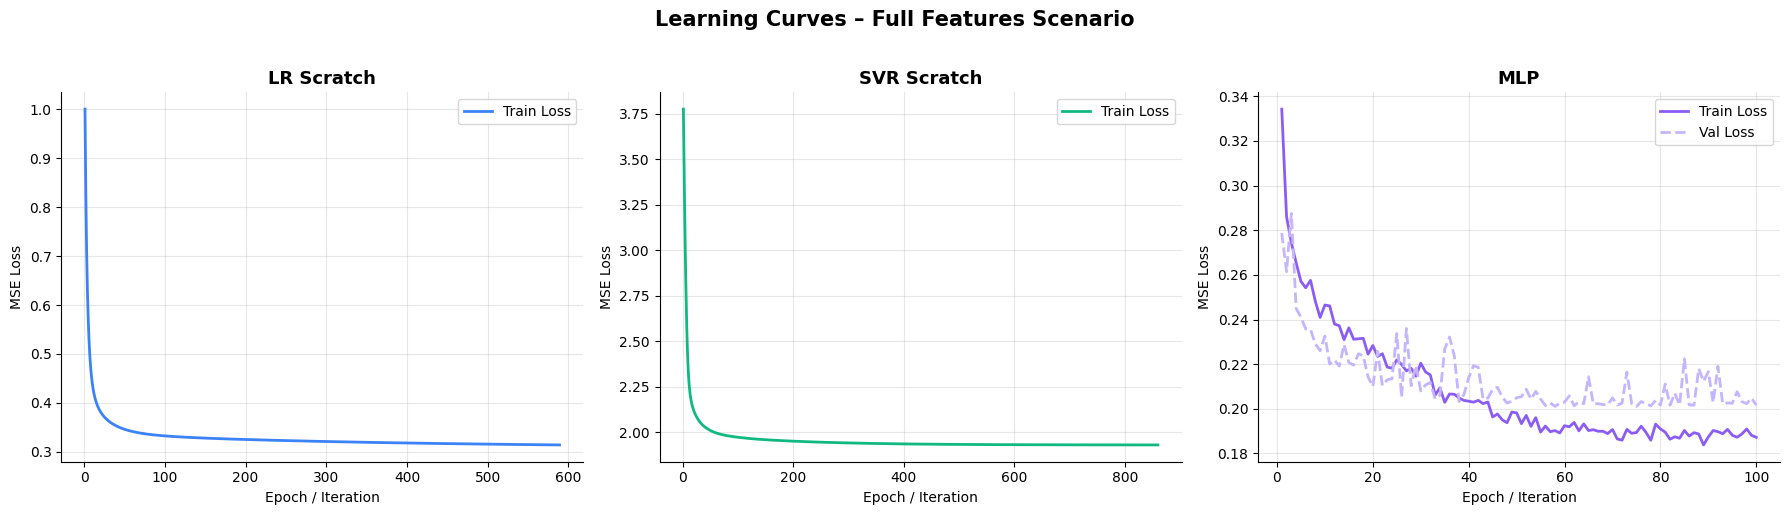

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Learning Curves – Full Features Scenario', fontsize=15, fontweight='bold', y=1.02)

model_names = ['LR Scratch', 'SVR Scratch', 'MLP']
colors = [('#3B82F6', '#93C5FD'), ('#10B981', '#6EE7B7'), ('#8B5CF6', '#C4B5FD')]

for ax, mname, (c_tr, c_val) in zip(axes, model_names, colors):
    tr_hist, val_hist = loss_store[('Full Features', mname)]
    epochs_x = range(1, len(tr_hist)+1)
    ax.plot(epochs_x, tr_hist, color=c_tr, lw=2, label='Train Loss')
    if val_hist:
        ax.plot(epochs_x, val_hist, color=c_val, lw=2, linestyle='--', label='Val Loss')
    ax.set_title(f'{mname}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch / Iteration')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

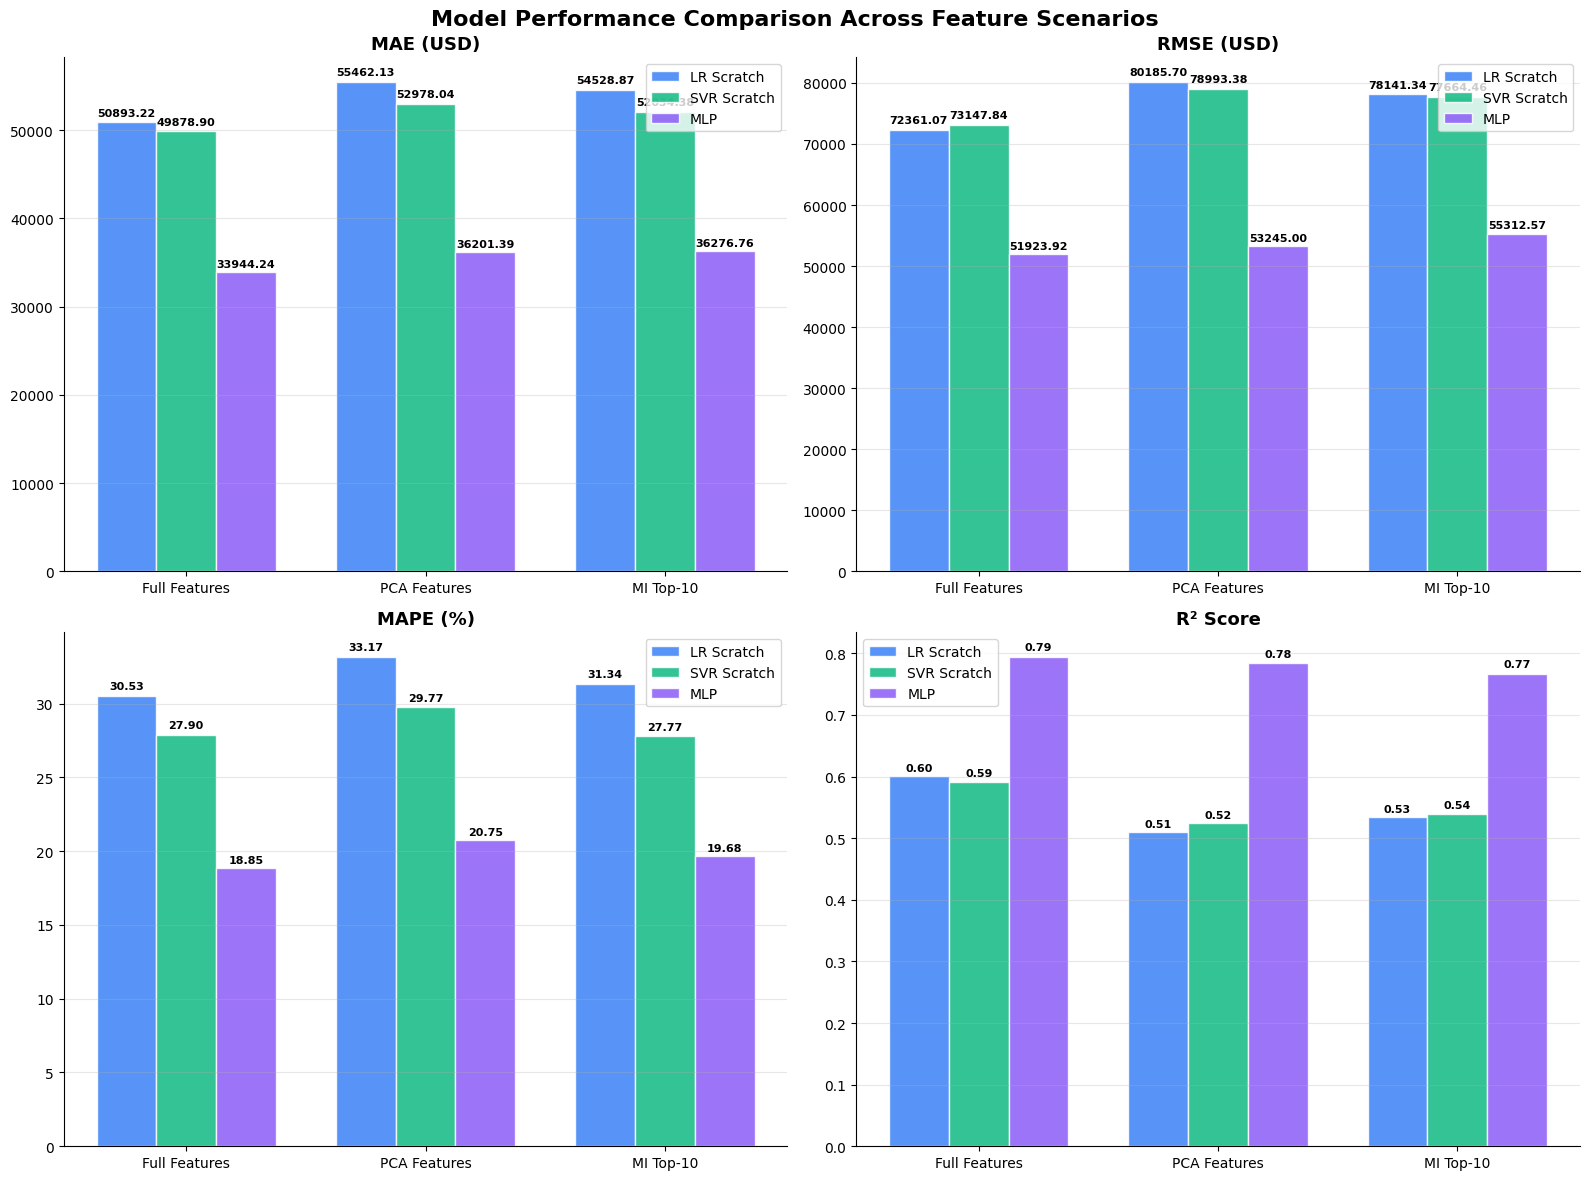

In [19]:
metrics_cols = ['MAE', 'RMSE', 'MAPE(%)', 'R2']
metric_labels = ['MAE (USD)', 'RMSE (USD)', 'MAPE (%)', 'R² Score']
model_order = ['LR Scratch', 'SVR Scratch', 'MLP']
sc_order = ['Full Features', 'PCA Features', 'MI Top-10']
bar_colors = ['#3B82F6', '#10B981', '#8B5CF6']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison Across Feature Scenarios', fontsize=16, fontweight='bold')

for idx, (metric, label) in enumerate(zip(metrics_cols, metric_labels)):
    ax = axes[idx // 2][idx % 2]
    x = np.arange(len(sc_order))
    width = 0.25
    for mi, (mname, color) in enumerate(zip(model_order, bar_colors)):
        vals = [df[(df['Scenario']==sc) & (df['Model']==mname)][metric].values[0]
                for sc in sc_order]
        bars = ax.bar(x + mi*width, vals, width, label=mname, color=color, alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(sc_order, fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(True, axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

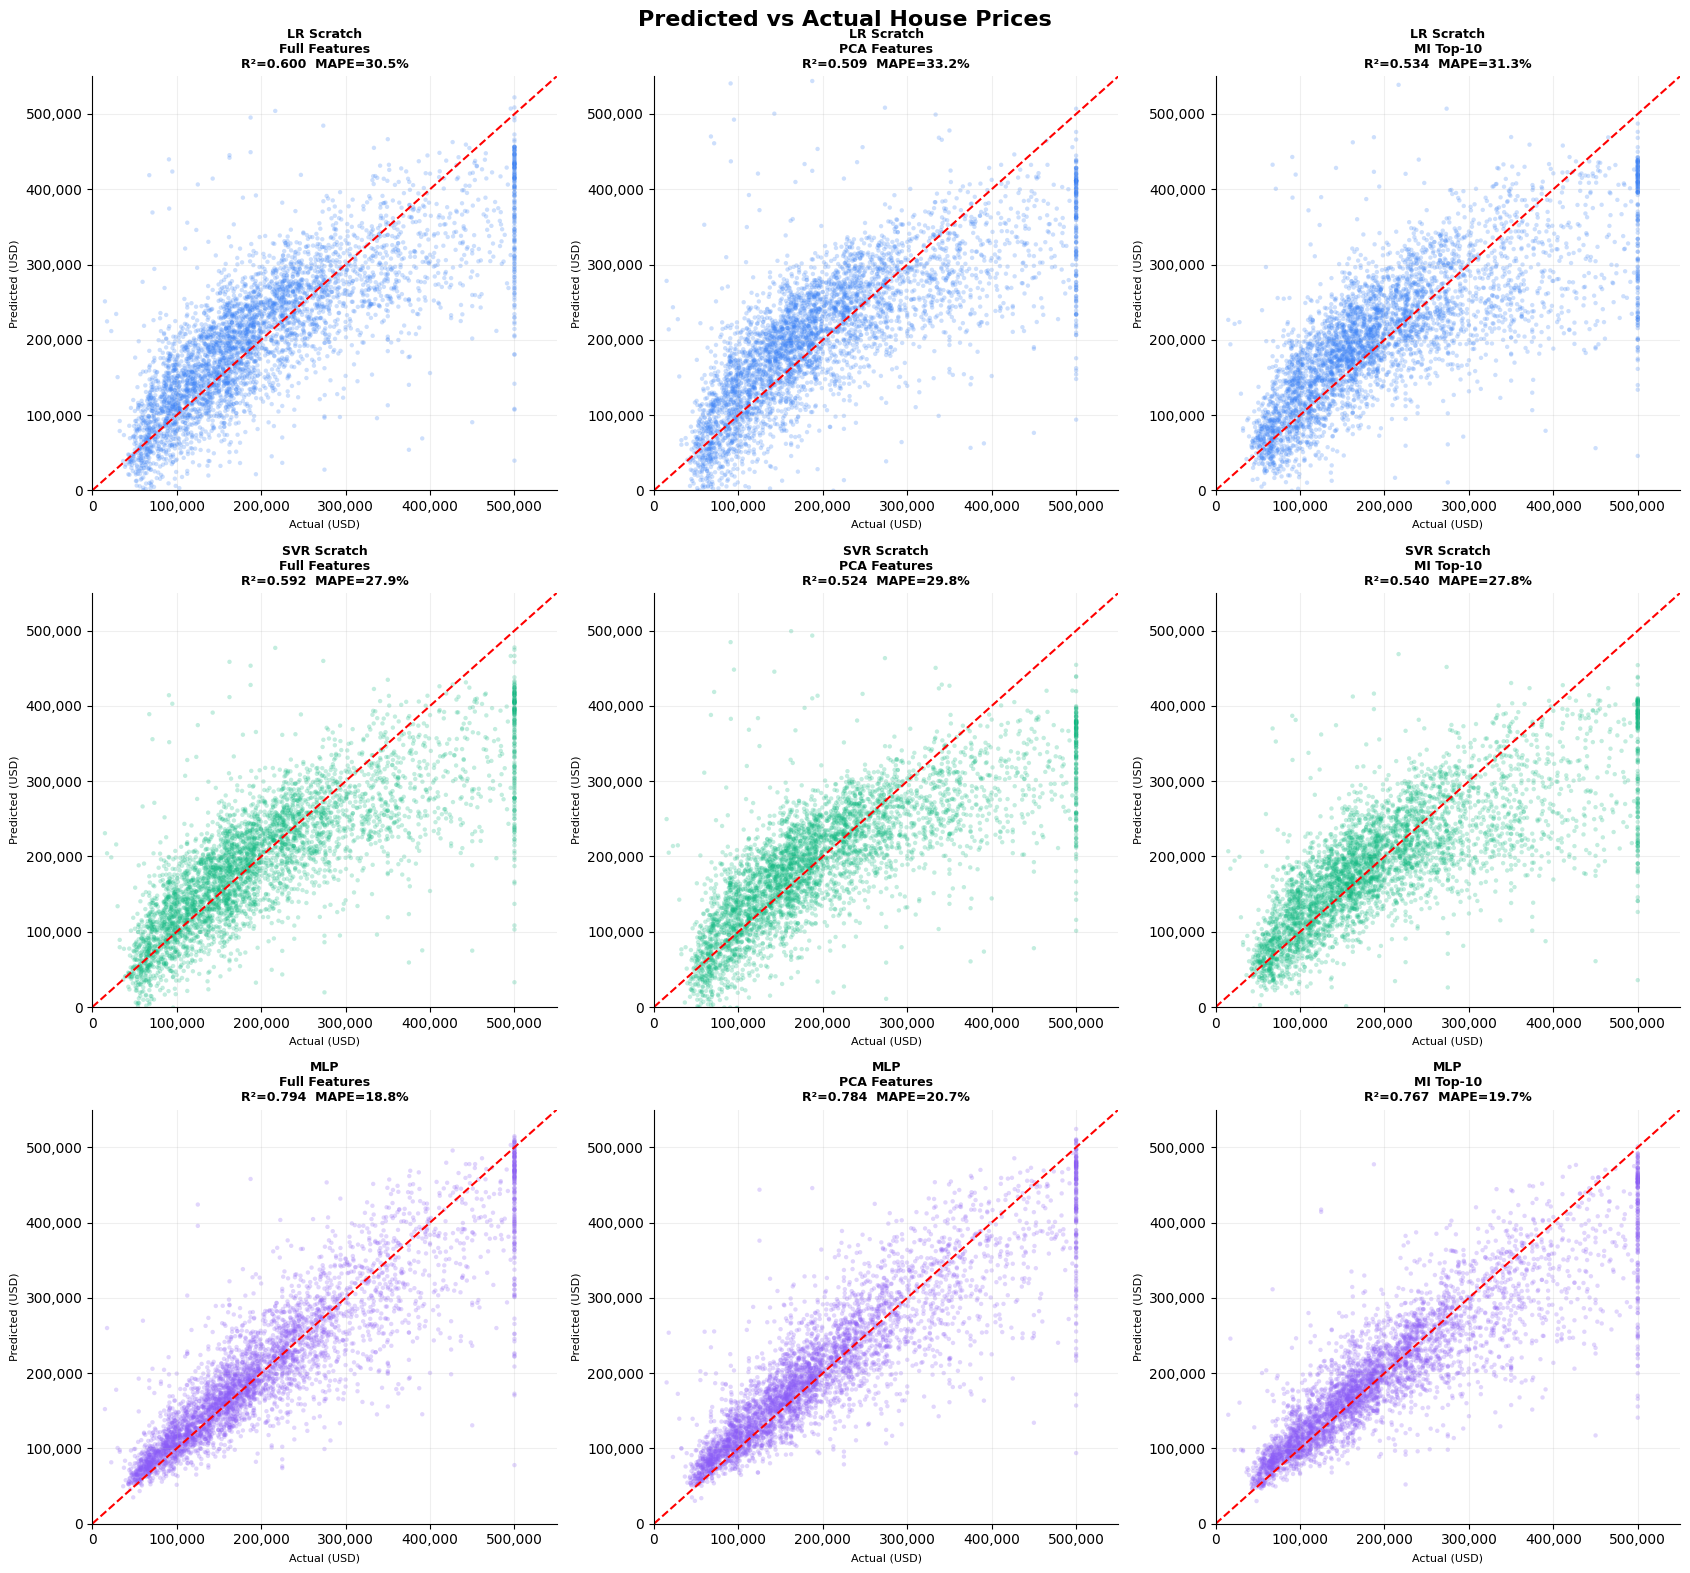

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(17, 16))
fig.suptitle('Predicted vs Actual House Prices', fontsize=16, fontweight='bold')

scatter_colors = {'LR Scratch': '#3B82F6', 'SVR Scratch': '#10B981', 'MLP': '#8B5CF6'}

for row, mname in enumerate(model_names):
    for col, sc_name in enumerate(sc_order):
        ax = axes[row][col]
        y_pred = pred_store[(sc_name, mname)]
        r2_val = df[(df['Scenario']==sc_name) & (df['Model']==mname)]['R2'].values[0]
        mape_val = df[(df['Scenario']==sc_name) & (df['Model']==mname)]['MAPE(%)'].values[0]

        ax.scatter(y_test, y_pred, alpha=0.25, s=10, color=scatter_colors[mname], edgecolors='none')
        
        # Limit to the realistic housing price range to make the plots wider and focused
        ax.set_xlim([0, 550000])
        ax.set_ylim([0, 550000])
        
        # Plot diagonal line
        ax.plot([0, 550000], [0, 550000], 'r--', lw=1.5)

        # Format ticks to regular numbers with commas
        ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
        ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

        ax.set_title(f'{mname}\n{sc_name}\nR²={r2_val:.3f}  MAPE={mape_val:.1f}%',
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('Actual (USD)', fontsize=8)
        ax.set_ylabel('Predicted (USD)', fontsize=8)
        ax.grid(True, alpha=0.2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [21]:
# Tạo bản sao để định dạng hiển thị đẹp mắt
display_df = df.copy()

# Định dạng các cột số tiền mặt (USD) với dấu phẩy phân tách hàng nghìn
display_df['MAE'] = display_df['MAE'].map('{:,.0f}'.format)
display_df['RMSE'] = display_df['RMSE'].map('{:,.0f}'.format)

# Định dạng các tỷ lệ phần trăm và R2 làm tròn số thập phân
display_df['MAPE(%)'] = display_df['MAPE(%)'].map('{:.2f}'.format)
display_df['R2'] = display_df['R2'].map('{:.4f}'.format)

# Định dạng thời gian chạy (mili-giây)
display_df['Train_ms'] = display_df['Train_ms'].map('{:.0f}'.format)
display_df['Inf_ms'] = display_df['Inf_ms'].map('{:.1f}'.format)

# Đổi tên các cột hiển thị cho chuyên nghiệp
display_df.columns = [
    'Scenario', 
    'Model', 
    'MAE (USD)', 
    'RMSE (USD)', 
    'MAPE (%)', 
    'R² Score', 
    'Train (ms)', 
    'Inf (ms)'
]

print('\n--- Final Scenario Comparison Results Table ---')
print(display_df.to_string(index=False))


--- Final Scenario Comparison Results Table ---
     Scenario       Model MAE (USD) RMSE (USD) MAPE (%) R² Score Train (ms) Inf (ms)
Full Features  LR Scratch    50,893     72,361    30.53   0.6004        213      0.3
Full Features SVR Scratch    49,879     73,148    27.90   0.5917       2243      0.4
Full Features         MLP    33,944     51,924    18.85   0.7943      65182      1.2
 PCA Features  LR Scratch    55,462     80,186    33.17   0.5093        151      0.3
 PCA Features SVR Scratch    52,978     78,993    29.77   0.5238       1822      0.3
 PCA Features         MLP    36,201     53,245    20.75   0.7837      64285      1.0
    MI Top-10  LR Scratch    54,529     78,141    31.34   0.5340        111      0.2
    MI Top-10 SVR Scratch    52,034     77,664    27.77   0.5397       1586      0.3
    MI Top-10         MLP    36,277     55,313    19.68   0.7665      65078      1.0
